##### Setup

###### Imports

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import ToTensor, Lambda

import numpy as np
import matplotlib.pyplot as plt

from svipy.vae import vaeEncoder, vaeDecoder, variationalAutoencoder, vqVariationalAutoencoder, autoencodingVariationalAutoencoder
from svipy.rbm import restrictedBoltzmannMachine
from svipy.model import reshape, earlyStopping

###### Load data

In [2]:
class imageOnlyDataset(torch.utils.data.Dataset):
    '''
    Class to extract only the images as labels not needed for VAEs.
    '''
    def __init__(self, original, index):
        self.__original = original
        self.__index = index

    @property
    def original(self):
        return self.__original

    @property
    def index(self):
        return self.__index

    def __len__(self):
        return len(self.original)

    def __getitem__(self, index):
        return self.original[index][self.index]

In [3]:
# ToTensor() scales eveything to [0, 1)
thresh = Lambda(lambda x: torch.where(ToTensor()(x) > 0.5, 1.0, 0.0))

# scatter_ to get a one-hot vector
onehot = Lambda(lambda y: torch.zeros(10, dtype=torch.float).scatter_(0, torch.tensor(y), value=1))

trainData = datasets.MNIST(root="../data", train=True, download=True, transform=thresh, target_transform=onehot)
testData = datasets.MNIST(root="../data", train=False, download=True, transform=thresh, target_transform=onehot)
# trainData = datasets.MNIST(root="../data", train=True, download=True) # , transform=thresh, target_transform=onehot)

trainImageData = imageOnlyDataset(trainData, 0)  # remove the labels as we dont need them
testImageData = imageOnlyDataset(testData, 0)
print(len(trainData), len(testData), len(trainImageData), len(testImageData))

60000 10000 60000 10000


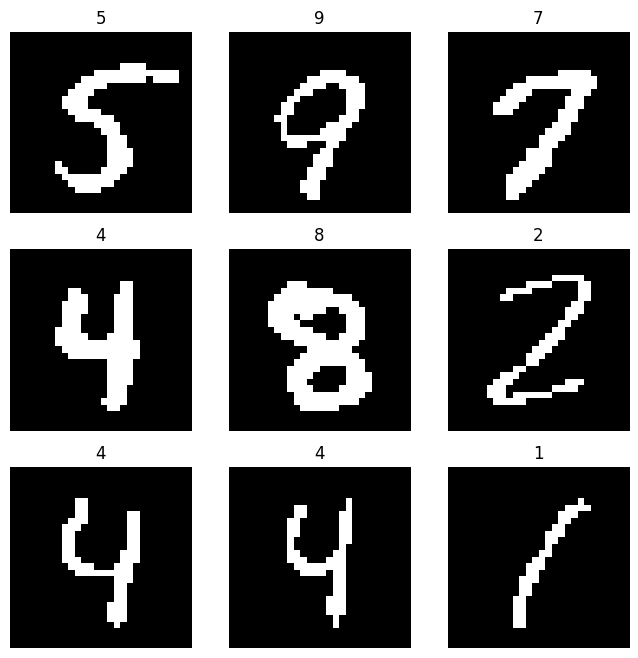

In [4]:
# show some randomly picked numbers
label_map = {k: str(k) for k in range(10)}

figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sidx = torch.randint(len(trainData), size=(1,)).item()
    img, label = trainData[sidx]
    figure.add_subplot(rows, cols, i)
    plt.title(label_map[torch.argmax(label, dim=0).item()])
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap='gray')
plt.show()

In [5]:
# inference
def latentSpaceRecons2D(n=30, figsize=15, scale=1.0):
    digit_size = 28
    figure = np.zeros((digit_size * n, digit_size * n))
    
    # linearly spaced coordinates corresponding in the 2D latent space
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            x_decoded = model.decoder(z_sample)[0].cpu().detach()
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size,
                   j * digit_size : (j + 1) * digit_size] = digit

    plt.figure(figsize=(figsize, figsize))
    
    # set axis ticks corresponding to latent values
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    plt.xticks(pixel_range, np.round(grid_x, 1))
    plt.yticks(pixel_range, np.round(grid_y, 1))

    # axis labels
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    
    plt.imshow(figure, cmap="Greys_r")
    plt.show()

###### Hardware Specs

In [6]:
cudaavailable = torch.cuda.is_available()
mpsavailable = torch.backends.mps.is_available()
curr_device = torch.cuda.current_device()

device = torch.device("cuda" if cudaavailable else "mps" if mpsavailable else "cpu")
device_count = torch.cuda.device_count() 
device_name =  torch.cuda.get_device_name(0)

print(f'Cuda available: {cudaavailable}')
print(f'Current device: {curr_device}')
print(f'Device: {device}')
print(f'Device count: {device_count}')
print(f'Device name: {device_name}')

Cuda available: True
Current device: 0
Device: cuda
Device count: 1
Device name: NVIDIA GeForce GTX 970


In [7]:
def latentSpaceRecons2D(n=30, figsize=15, scale=1.0):
    digit_size = 28
    figure = np.zeros((digit_size * n, digit_size * n))
    
    # linearly spaced coordinates corresponding in the 2D latent space
    grid_x = np.linspace(-scale, scale, n)
    grid_y = np.linspace(-scale, scale, n)[::-1]

    for i, yi in enumerate(grid_y):
        for j, xi in enumerate(grid_x):
            z_sample = torch.tensor([[xi, yi]], dtype=torch.float32).to(device)
            x_decoded = model.decoder(z_sample)[0].cpu().detach()
            digit = x_decoded[0].reshape(digit_size, digit_size)
            figure[i * digit_size : (i + 1) * digit_size,
                   j * digit_size : (j + 1) * digit_size] = digit

    plt.figure(figsize=(figsize, figsize))
    
    # set axis ticks corresponding to latent values
    start_range = digit_size // 2
    end_range = n * digit_size + start_range
    pixel_range = np.arange(start_range, end_range, digit_size)
    plt.xticks(pixel_range, np.round(grid_x, 1))
    plt.yticks(pixel_range, np.round(grid_y, 1))

    # axis labels
    plt.xlabel("z[0]")
    plt.ylabel("z[1]")
    
    plt.imshow(figure, cmap="Greys_r")
    plt.show()


##### MNIST

In [7]:
class mnistDecoder(vaeDecoder):
    '''
    VAE decoder with cross entropy loss (canonical decoder uses MSE)
    '''
    @staticmethod
    def reconstructionLoss(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
        bce = torch.nn.functional.binary_cross_entropy(recon, x, reduction='none')
        return torch.mean(torch.sum(torch.flatten(bce, start_dim=1), dim=1))

In [8]:
# build the encoder and decoder networks
hid_dim = 2

encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Flatten(), # reshape([3136]), # 
                        nn.Linear(3136, hid_dim + hid_dim))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dim, 32 * 7 * 7),
                        nn.ReLU(),
                        reshape([32, 7, 7]),
                        nn.ConvTranspose2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1),
                        nn.Sigmoid())
decoder = mnistDecoder(decoder)

model = variationalAutoencoder(encoder, decoder).to(device)

In [9]:
learning_rate = 0.001
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.1, mode='min', restoreBestWeights=True)

In [10]:
model.trainLoop(trainLoader, optimizer, epochs, 
                reportIters=100, scheduler=None,
                checkpointPath='../checkpoints/mnist_vae/',
                checkPointName='vae_2',
                validDataLoader=validLoader,
                earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 212.853745 reconLoss: 209.802582 klLoss: 3.051158[12800/60000]
totalLoss: 185.809326 reconLoss: 182.529144 klLoss: 3.280182[25600/60000]
totalLoss: 172.833298 reconLoss: 169.602432 klLoss: 3.230861[38400/60000]
totalLoss: 173.589020 reconLoss: 170.311859 klLoss: 3.277163[51200/60000]
Validation Error: 167.525231
Epoch 2
-------------------------------
totalLoss: 167.405716 reconLoss: 164.146729 klLoss: 3.258984[12800/60000]
totalLoss: 159.239365 reconLoss: 155.966064 klLoss: 3.273299[25600/60000]
totalLoss: 151.349304 reconLoss: 147.972778 klLoss: 3.376526[38400/60000]
totalLoss: 167.864426 reconLoss: 164.664520 klLoss: 3.199906[51200/60000]
Validation Error: 160.646663
Epoch 3
-------------------------------
totalLoss: 161.292557 reconLoss: 157.988190 klLoss: 3.304363[12800/60000]
totalLoss: 151.782242 reconLoss: 148.519836 klLoss: 3.262410[25600/60000]
totalLoss: 168.335983 reconLoss: 165.158829 klLoss: 3.177156[38400/60000]
totalLos

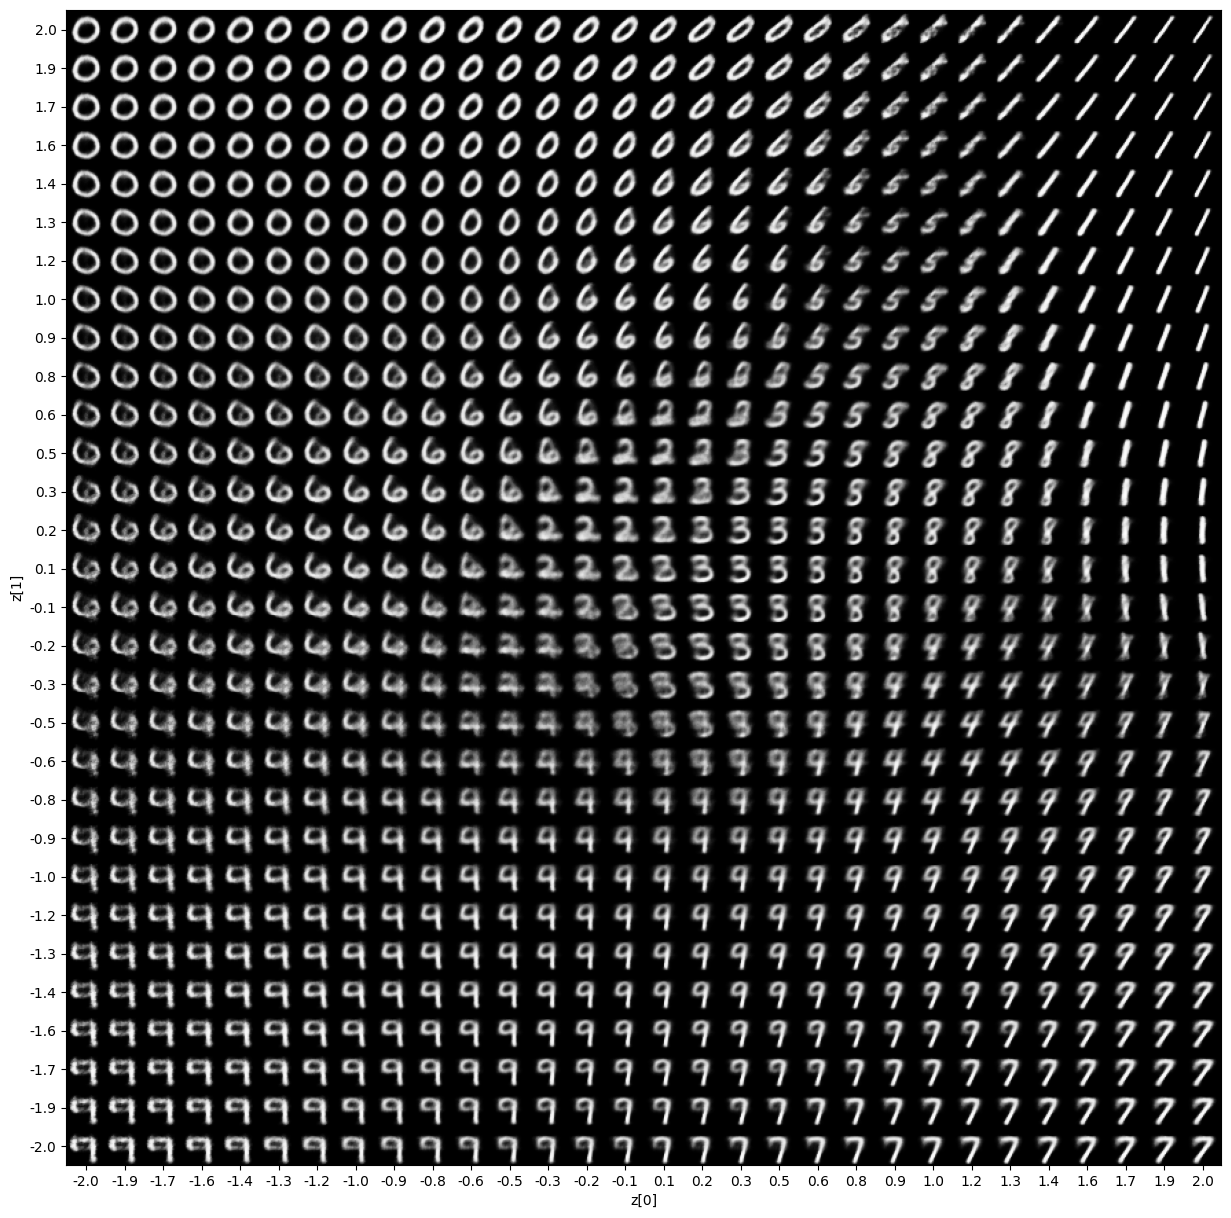

In [11]:
latentSpaceRecons2D(scale=2.0, n=30)

In [12]:
class mnistDecoder(vaeDecoder):
    """
    Replace sum of error with mean of error - helps to 
    make error independent of dimensionality
    """
    @staticmethod
    def reconstructionLoss(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
        bce = torch.nn.functional.binary_cross_entropy(recon, x, reduction='none')
        return torch.mean(torch.mean(torch.flatten(bce, start_dim=1), dim=1))

In [18]:
# build the encoder and decoder networks
hid_dim = 2

encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Flatten(), # reshape([3136]), # 
                        nn.Linear(3136, hid_dim + hid_dim))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dim, 32 * 7 * 7),
                        nn.ReLU(),
                        reshape([32, 7, 7]),
                        nn.ConvTranspose2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1),
                        nn.Sigmoid())
decoder = mnistDecoder(decoder)

model = variationalAutoencoder(encoder, decoder).to(device)

In [19]:
learning_rate = 0.001
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.1, mode='min', restoreBestWeights=True)

In [20]:
model.trainLoop(trainLoader, optimizer, epochs, 
                reportIters=100, scheduler=None,
                checkpointPath='../checkpoints/mnist_vae/',
                checkPointName='vae_2_avg',
                validDataLoader=validLoader,
                earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 0.270107 reconLoss: 0.270086 klLoss: 0.000021[12800/60000]
totalLoss: 0.264615 reconLoss: 0.264611 klLoss: 0.000004[25600/60000]
totalLoss: 0.256805 reconLoss: 0.256803 klLoss: 0.000001[38400/60000]
totalLoss: 0.262567 reconLoss: 0.262566 klLoss: 0.000001[51200/60000]
Validation Error: 0.263657
Epoch 2
-------------------------------
totalLoss: 0.265244 reconLoss: 0.265244 klLoss: 0.000000[12800/60000]
totalLoss: 0.254011 reconLoss: 0.254011 klLoss: 0.000000[25600/60000]
totalLoss: 0.268045 reconLoss: 0.268045 klLoss: 0.000000[38400/60000]
totalLoss: 0.264914 reconLoss: 0.264913 klLoss: 0.000000[51200/60000]
Validation Error: 0.263017
Epoch 3
-------------------------------
totalLoss: 0.267799 reconLoss: 0.267799 klLoss: 0.000000[12800/60000]
totalLoss: 0.274919 reconLoss: 0.274919 klLoss: 0.000000[25600/60000]
totalLoss: 0.274239 reconLoss: 0.274239 klLoss: 0.000000[38400/60000]
totalLoss: 0.267366 reconLoss: 0.267366 klLoss: 0.000000

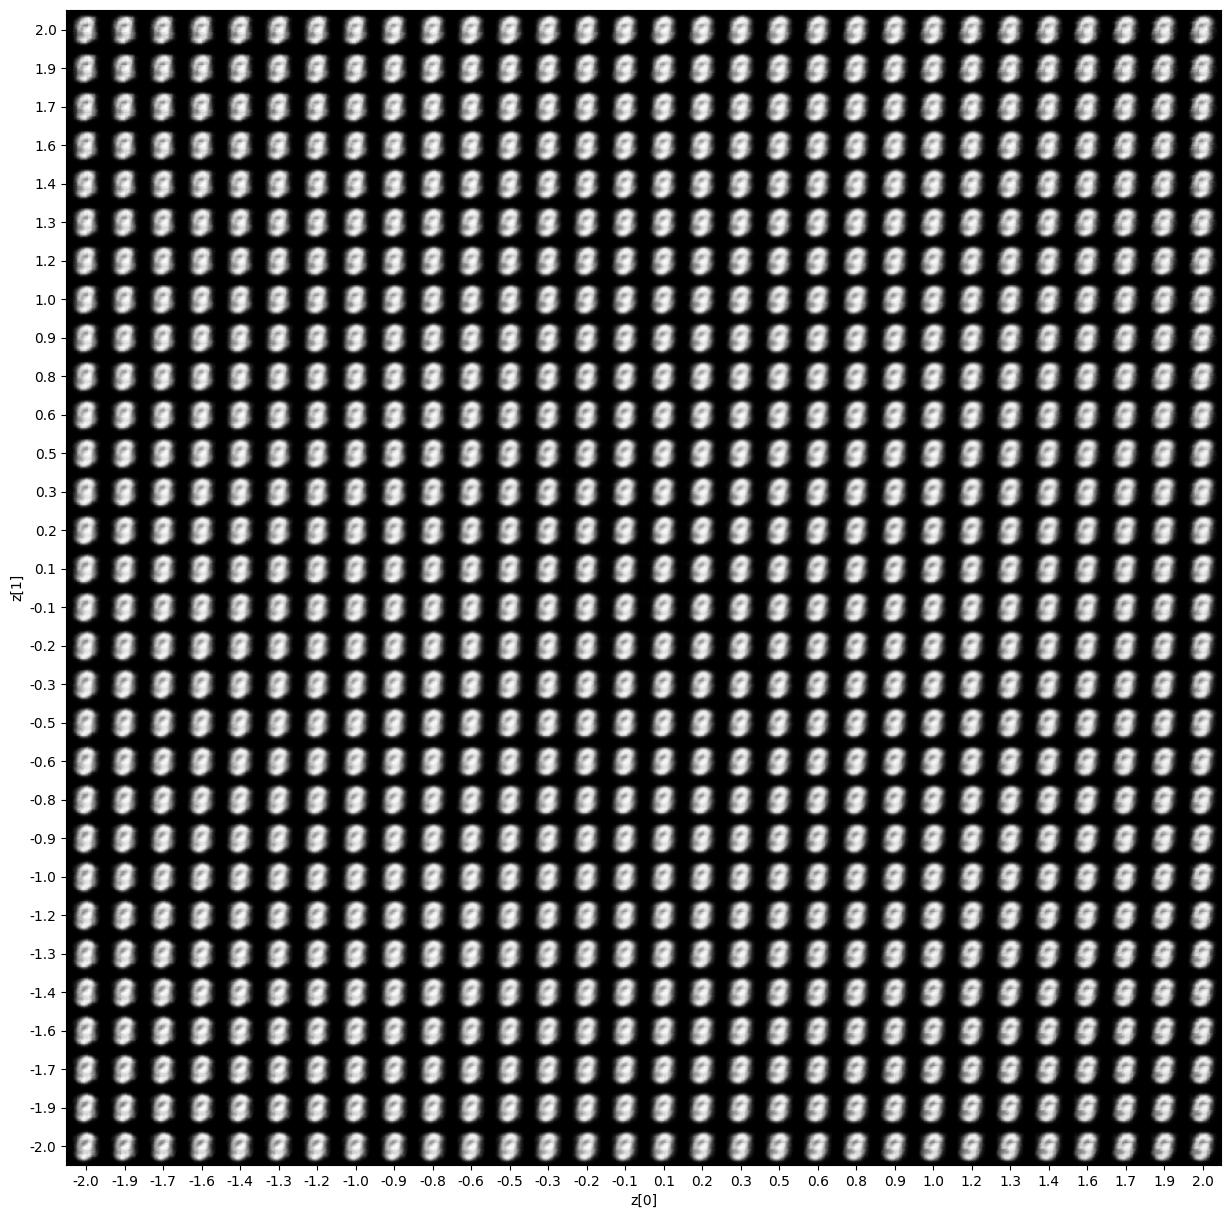

In [21]:
latentSpaceRecons2D(scale=2.0, n=30)

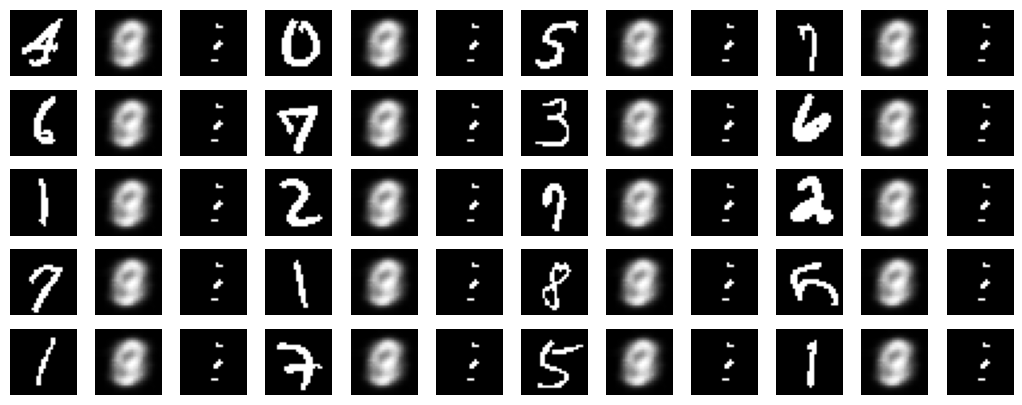

In [22]:
nCols = 12
nRows = 5

figure = plt.figure(figsize=(13, 5))
model.eval()

with torch.no_grad():
    for i in range(4 * nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        img, label = trainData[sidx]
        figure.add_subplot(nRows, nCols, 3 * i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')
        
        img = model.decode(model.encode(trainImageData[sidx].unsqueeze(0).to(device))[0])
        img = img.cpu().detach()
        figure.add_subplot(nRows, nCols, 3 * i + 2)
        plt.axis("off")
        plt.imshow(img.numpy().squeeze(), cmap='gray')

        figure.add_subplot(nRows, nCols, 3 * i + 3)
        plt.axis("off")
        plt.imshow(torch.where(img > 0.5, 1.0, 0.0).numpy().squeeze(), cmap='gray')

plt.show()

In [24]:
# Diagnostics
# def plotPriorSamples(model, hidDim, nSamples=16, device=device):
#     """
#     Decode samples from the prior z ~ N(0, I) directly -- not from
#     encoding any real input. Tests whether the model is actually a
#     working generative model. A collapsed posterior will produce the
#     same (or near-identical) blurry image every time, regardless of z.
#     """
#     model.eval()
#     with torch.no_grad():
#         z = torch.randn(nSamples, hidDim, device=device)
#         samples = model.decode(z)

#     cols = 4
#     rows = nSamples // cols + (1 if nSamples % cols else 0)
#     figure = plt.figure(figsize=(8, 8))
     
#     for i in range(nSamples):
#         figure.add_subplot(rows, cols, i + 1)
#         plt.axis("off")
#         plt.imshow(samples[i].cpu().squeeze(), cmap='gray')
#         plt.suptitle("Samples decoded from the prior  z ~ N(0, I)")
        
#     plt.show()


# def plotReconstructionGrid(model, dataset, nDigits=8, device=device):
#     """
#     Reconstruct several DIFFERENT real inputs side by side. A collapsed
#     posterior produces the same output regardless of the input -- visible
#     here even when the aggregate reconLoss number looks fine (background-
#     dominated binary images can hide collapse in a single averaged number).
#     """
#     model.eval()
#     indices = torch.randperm(len(dataset))[:nDigits]
#     imgs = torch.stack([dataset[int(i)] for i in indices]).to(device)
    
#     with torch.no_grad():
#         recon, _, _ = model.forward(imgs)
#         figure = plt.figure(figsize=(2 * nDigits, 4))
#         for i in range(nDigits):
#             figure.add_subplot(2, nDigits, i + 1)
#             plt.axis("off")
#             if i == 0:
#                 plt.title("input")
#             plt.imshow(imgs[i].cpu().squeeze(), cmap='gray')
                
#             figure.add_subplot(2, nDigits, nDigits + i + 1)
#             plt.axis("off")
#             if i == 0:
#                 plt.title("recon")
#             plt.imshow(recon[i].cpu().squeeze(), cmap='gray')
    
#     plt.show()


def activeUnits(model, dataset, threshold=0.01, batchSize=256, device=device):
    """
    Burda et al.'s "active units" statistic: Var_x[mu(x)] per latent
    dimension, computed across the dataset. A dimension whose posterior
    mean barely moves across different inputs is \"dead\" -- carrying no
    information about x, regardless of what its logVar looks like.
    """
    
    model.eval()
    loader = DataLoader(dataset, batch_size=batchSize, shuffle=False)
    means = []
    
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            zMean, _ = model.encode(data)
            means.append(zMean.cpu())
            
    means = torch.cat(means, dim=0)
    
    variance = means.var(dim=0)
    nActive = 0
    for i, v in enumerate(variance):
        active = v.item() > threshold
        nActive += active
        print(f"dim {i}: Var_x[mu] = {v.item():.6f}  ({'active' if active else 'DEAD'})")
        print(f"{nActive}/{len(variance)} active units (threshold={threshold})")
              
    return variance


In [30]:
# plotPriorSamples(model, 2)
# plotReconstructionGrid(model, trainImageData)
activeUnits(model, trainImageData)

dim 0: Var_x[mu] = 0.000000  (DEAD)
0/2 active units (threshold=0.01)
dim 1: Var_x[mu] = 0.000000  (DEAD)
0/2 active units (threshold=0.01)


tensor([3.6462e-07, 4.2397e-07])

In [40]:
# build the encoder and decoder networks
hid_dim = 2
beta = 0.01

encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Flatten(), # reshape([3136]), # 
                        nn.Linear(3136, hid_dim + hid_dim))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dim, 32 * 7 * 7),
                        nn.ReLU(),
                        reshape([32, 7, 7]),
                        nn.ConvTranspose2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1),
                        nn.Sigmoid())
decoder = mnistDecoder(decoder)

model = variationalAutoencoder(encoder, decoder, beta).to(device)

In [41]:
learning_rate = 1e-3
batch_size = 128
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=3, minDelta=0.001, mode='min', restoreBestWeights=True)

In [42]:
model.trainLoop(trainLoader, optimizer, epochs, 
                reportIters=100, scheduler=None,
                checkpointPath='../checkpoints/mnist_bvae/',
                checkPointName='bvae_2_2',
                validDataLoader=validLoader,
                earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 0.267442 reconLoss: 0.257898 klLoss: 0.954365[12800/60000]
totalLoss: 0.256994 reconLoss: 0.243830 klLoss: 1.316410[25600/60000]
totalLoss: 0.245200 reconLoss: 0.230640 klLoss: 1.455999[38400/60000]
totalLoss: 0.226804 reconLoss: 0.211081 klLoss: 1.572360[51200/60000]
Validation Error: 0.229452
Epoch 2
-------------------------------
totalLoss: 0.215852 reconLoss: 0.199835 klLoss: 1.601772[12800/60000]
totalLoss: 0.218026 reconLoss: 0.203088 klLoss: 1.493869[25600/60000]
totalLoss: 0.216864 reconLoss: 0.201331 klLoss: 1.553295[38400/60000]
totalLoss: 0.224691 reconLoss: 0.207457 klLoss: 1.723463[51200/60000]
Validation Error: 0.220819
Epoch 3
-------------------------------
totalLoss: 0.226942 reconLoss: 0.210551 klLoss: 1.639107[12800/60000]
totalLoss: 0.220856 reconLoss: 0.204286 klLoss: 1.657035[25600/60000]
totalLoss: 0.225342 reconLoss: 0.208512 klLoss: 1.682983[38400/60000]
totalLoss: 0.212450 reconLoss: 0.195234 klLoss: 1.721663

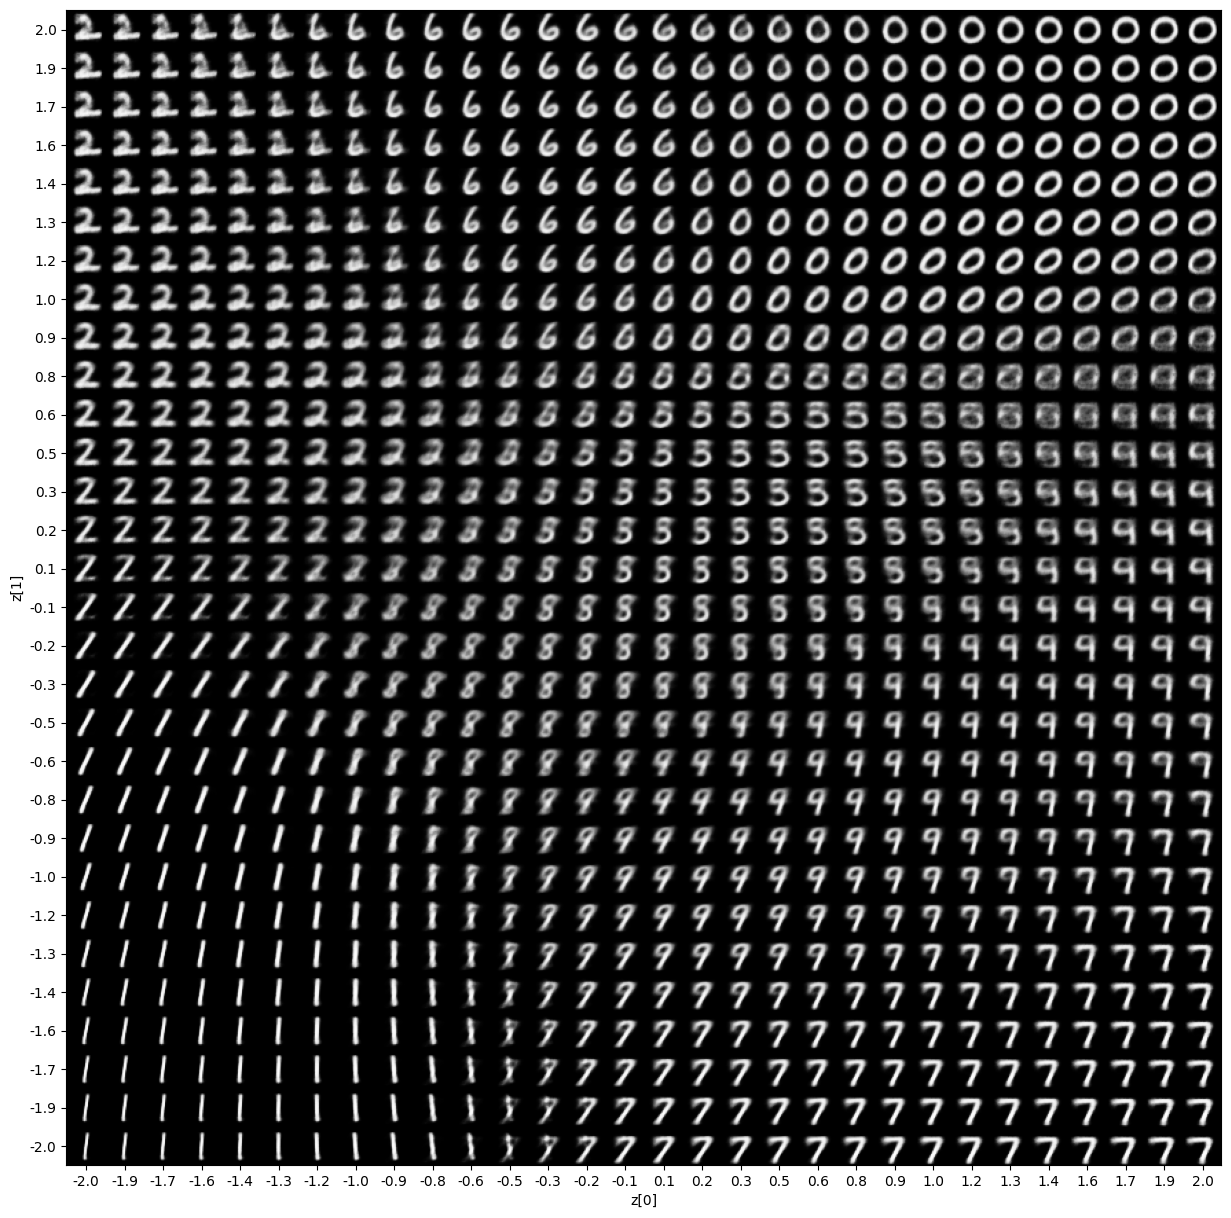

In [43]:
latentSpaceRecons2D(scale=2.0, n=30)

###### VQ-VAE

In [8]:
class mnistDecoder(vaeDecoder):
    '''
    VAE decoder with cross entropy loss (canonical decoder uses MSE)
    '''
    @staticmethod
    def reconstructionLoss(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
        bce = torch.nn.functional.binary_cross_entropy(recon, x, reduction='none')
        return torch.mean(torch.sum(torch.flatten(bce, start_dim=1), dim=1))

In [9]:
# build the encoder and decoder networks
hid_dim = 64
n_embeds = 10
beta = 1.
data_var = 0.2

encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU())
# encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.Sigmoid())
decoder = mnistDecoder(decoder)

model = vqVariationalAutoencoder(encoder, decoder, nDims=hid_dim, 
                                 nEmbeddings=n_embeds, beta=beta,
                                 data_var=data_var).to(device)

In [13]:
learning_rate = 1e-3
batch_size = 64
epochs = 50

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=5, minDelta=0.05, mode='min', restoreBestWeights=True)

In [14]:
def gradNorm(loss, params, retain_graph):
    grads = torch.autograd.grad(loss, params, retain_graph=retain_graph, allow_unused=True)
    return torch.sqrt(sum(g.pow(2).sum() for g in grads if g is not None)).item()

def compareLossScales(model, batch):
    model.train()
    encoderParams = list(model.encoder.parameters())

    losses = model.computeLoss(batch)

    reconGradNorm = gradNorm(losses['reconLoss'], encoderParams, retain_graph=True)
    vqGradNorm = gradNorm(losses['vqLoss'], encoderParams, retain_graph=False)

    print(f"recon grad norm (encoder): {reconGradNorm:.4f}")
    print(f"vq grad norm (encoder):    {vqGradNorm:.4f}")
    print(f"ratio reconGradNorm/vqGradNorm -> suggested data_var: {reconGradNorm / vqGradNorm:.4f}")

batch = next(iter(trainLoader)).to(device)
suggestedDataVar = compareLossScales(model, batch)

RuntimeError: Input type (torch.cuda.FloatTensor) and weight type (torch.FloatTensor) should be the same

recon grad norm (encoder): 0.0427
vq grad norm (encoder):    0.2704
ratio reconGradNorm/vqGradNorm -> suggested data_var: 0.1579


In [21]:
model.trainLoop(trainLoader, optimizer, epochs, 
                reportIters=100, scheduler=None,
                checkpointPath='../checkpoints/mnist_vqvae/',
                checkPointName='vqvae_16_10',
                validDataLoader=validLoader,
                earlyStopper=stopper)

Epoch 1
-------------------------------
totalLoss: 2.499004 reconLoss: 0.060528 codeLoss: 0.644219 commLoss: 0.644219 vqLoss: 1.288437[ 6400/60000]
totalLoss: 2.540606 reconLoss: 0.059957 codeLoss: 0.670735 commLoss: 0.670735 vqLoss: 1.341470[12800/60000]
totalLoss: 2.378539 reconLoss: 0.051331 codeLoss: 0.675957 commLoss: 0.675957 vqLoss: 1.351913[19200/60000]
totalLoss: 2.367985 reconLoss: 0.048284 codeLoss: 0.701154 commLoss: 0.701154 vqLoss: 1.402307[25600/60000]
totalLoss: 2.511159 reconLoss: 0.048343 codeLoss: 0.772150 commLoss: 0.772150 vqLoss: 1.544300[32000/60000]
totalLoss: 2.635343 reconLoss: 0.050798 codeLoss: 0.809694 commLoss: 0.809694 vqLoss: 1.619388[38400/60000]
totalLoss: 2.815533 reconLoss: 0.049161 codeLoss: 0.916161 commLoss: 0.916161 vqLoss: 1.832322[44800/60000]
totalLoss: 2.373935 reconLoss: 0.046782 codeLoss: 0.719147 commLoss: 0.719147 vqLoss: 1.438294[51200/60000]
totalLoss: 2.253114 reconLoss: 0.043095 codeLoss: 0.695612 commLoss: 0.695612 vqLoss: 1.391223[5

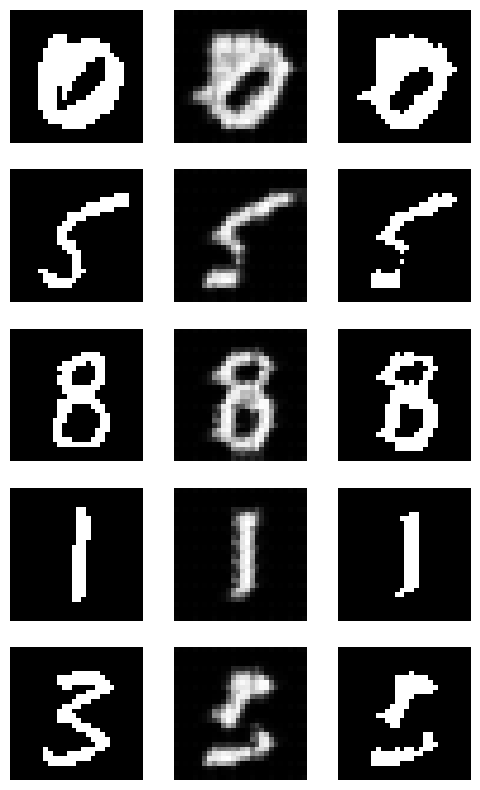

In [22]:
nCols = 3
nRows = 5

figure = plt.figure(figsize=(6, 10))
model.eval()

with torch.no_grad():
    for i in range(nRows):
        sidx = torch.randint(len(trainData), size=(1,)).item()
        img, label = trainData[sidx]
        figure.add_subplot(nRows, nCols, 3 * i + 1)
        plt.axis("off")
        plt.imshow(img.squeeze(), cmap='gray')
        
        img = model.decode(model.encode(trainImageData[sidx].unsqueeze(0).to(device)))
        img = img.cpu().detach()
        figure.add_subplot(nRows, nCols, 3 * i + 2)
        plt.axis("off")
        plt.imshow(img.numpy().squeeze(), cmap='gray')

        figure.add_subplot(nRows, nCols, 3 * i + 3)
        plt.axis("off")
        plt.imshow(torch.where(img > 0.5, 1.0, 0.0).numpy().squeeze(), cmap='gray')

plt.show()

###### Autoencoding VAE

In [23]:
class mnistDecoder(vaeDecoder):
    @staticmethod
    def reconstructionLoss(x: torch.Tensor, recon: torch.Tensor) -> torch.Tensor:
        bce = torch.nn.functional.binary_cross_entropy(recon, x, reduction='none')
        return torch.mean(torch.sum(torch.flatten(bce, start_dim=1), dim=1))
        # return torch.mean(bce)

In [24]:
# build the encoder and decoder networks
hid_dim = 2

encoder = nn.Sequential(nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1),
                        nn.ReLU(),
                        nn.Flatten(), # reshape([3136]), # 
                        nn.Linear(3136, hid_dim + hid_dim))
encoder = vaeEncoder(encoder)

decoder = nn.Sequential(nn.Linear(hid_dim, 32 * 7 * 7),
                        nn.ReLU(),
                        reshape([32, 7, 7]),
                        nn.ConvTranspose2d(in_channels=32, out_channels=64, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=3, stride=2, padding=1, output_padding=1),
                        nn.ReLU(),
                        nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1),
                        nn.Sigmoid())
decoder = mnistDecoder(decoder)

model = autoencodingVariationalAutoencoder(encoder, decoder, rho=0.98).to(device)

In [25]:
learning_rate = 1e-3
batch_size = 128
epochs = 25

trainLoader = DataLoader(trainImageData, batch_size=batch_size, shuffle=True)
validLoader = DataLoader(testImageData, batch_size=batch_size, shuffle=True)
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
stopper = earlyStopping(patience=5, minDelta=0.05, mode='min', restoreBestWeights=True)

In [26]:
model.trainLoop(trainLoader, optimizer, epochs, 
                reportIters=100, scheduler=None,
                checkpointPath='../checkpoints/mnist_avae/',
                checkPointName='avae_98',
                validDataLoader=validLoader,
                earlyStopper=stopper)

Epoch 1
-------------------------------


NameError: name 'np' is not defined

In [ ]:
plot_latent_space(scale=3.0, n=30)